<a href="https://colab.research.google.com/github/Sruthi051006/sruthi-codeboosters-2026/blob/main/Day-2/mini_project_Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

all libraries imported
pandas version: 2.2.2
sql version: 2.6.0


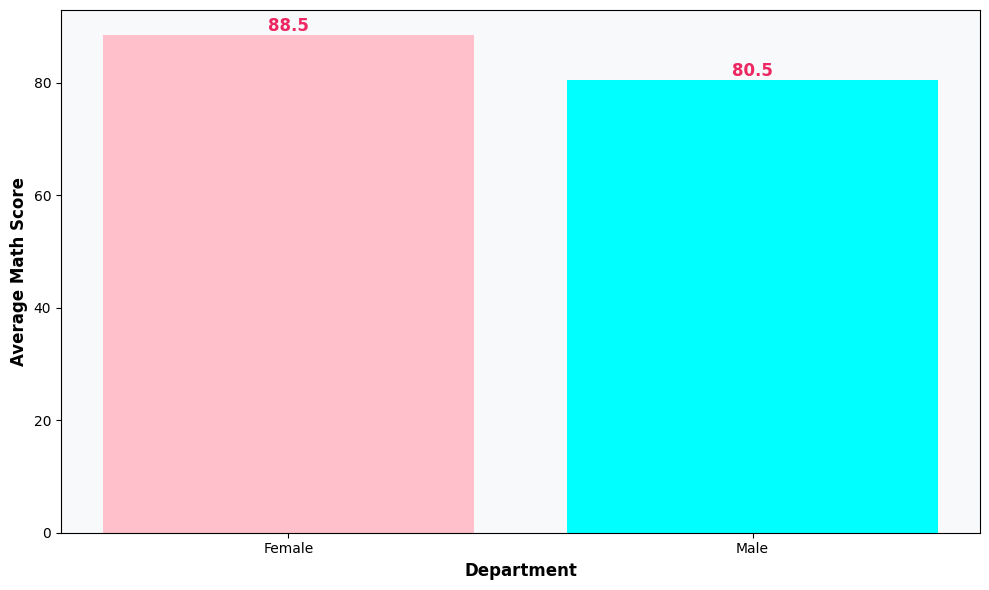

In [9]:
#step-1 importing the libraries
#pandas is to fetch the data  from the dataset
#matplotlib.pyplot visualization
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')#ignores the warnings

print("all libraries imported")
print(f"pandas version: {pd.__version__}")
print(f"sql version: {sqlite3.version}")

df = pd.read_csv('student_performance.csv')


conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count = cursor.fetchone()[0]


chart1_sql = """
    SELECT gender, ROUND(AVG(attendance_percentage), 2) AS avg_percentage
    FROM students
    GROUP BY gender
    ORDER BY avg_percentage DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#FFC0CB', '#00FFFF']

bars = ax.bar(
    chart1_data['gender'],
    chart1_data['avg_percentage'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.0
)

for bar in bars:
  height = bar.get_height()

  ax.text(
      bar.get_x() + bar.get_width()/ 2,
      height + 0.0,
      f'{height:.1f}',
      ha='center' , va='bottom',
      fontsize=12 , fontweight='bold',
      color='#EC2761'

  )


# X-axis label
ax.set_xlabel(
    'Department',
    fontsize=12,
    fontweight='bold'
)

# Y-axis label
ax.set_ylabel(
    'Average Math Score',
    fontsize=12,
    fontweight='bold'
)

# Background color
ax.set_facecolor('#F8F9FA')

# Grid lines
ax.grid(
    axis='y',
    linestyle='',
    alpha=0.5
)


# Adjust layout
plt.tight_layout()

# Show chart
plt.show()



all libraries imported
pandas version: 2.2.2
sql version: 2.6.0


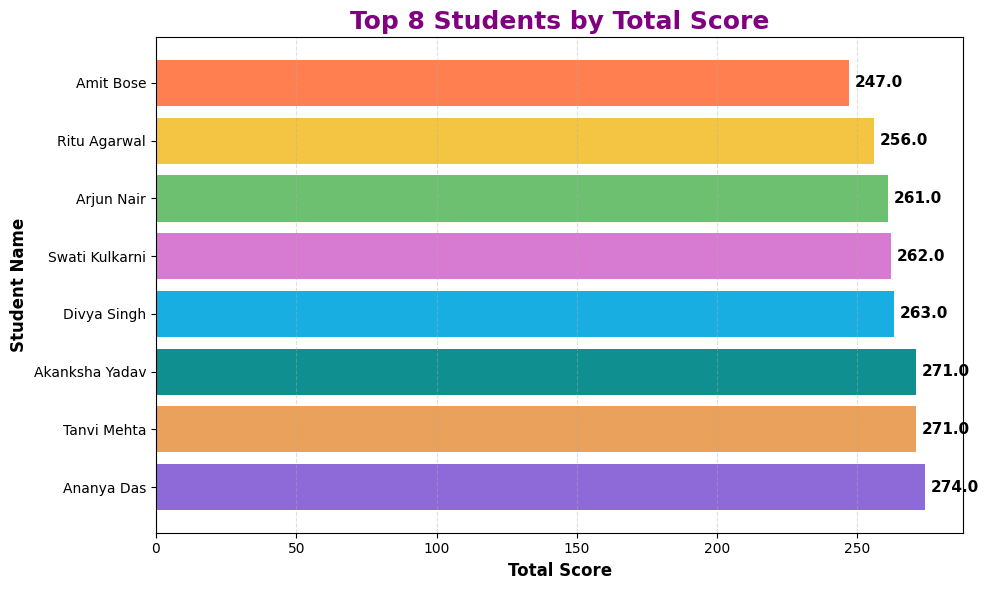

In [15]:
#step-1 importing the libraries
#pandas is to fetch the data  from the dataset
#matplotlib.pyplot visualization
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')#ignores the warnings

print("all libraries imported")
print(f"pandas version: {pd.__version__}")
print(f"sql version: {sqlite3.version}")

df = pd.read_csv('student_performance.csv')


conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count = cursor.fetchone()[0]

# Query to get Top 8 students based on total score
chart2_sql = """
    SELECT name,
           (math_score + science_score + english_score) AS total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 8
"""

chart2_data = pd.read_sql_query(chart2_sql, conn)

# Plot
plt.figure(figsize=(10, 6))

bars = plt.barh(
    chart2_data['name'],
    chart2_data['total_score'],
    color=['#8e6ad8', '#e9a15b', '#0f8f8f', '#19aee2',
           '#d67ad2', '#6cc070', '#f4c542', '#ff7f50']
)

# Title and labels
plt.title("Top 8 Students by Total Score",
          fontsize=18,
          fontweight='bold',
          color='purple')

plt.xlabel("Total Score", fontsize=12, fontweight='bold')
plt.ylabel("Student Name", fontsize=12, fontweight='bold')

# Add score labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2,
             bar.get_y() + bar.get_height()/2,
             f'{width:.1f}',
             va='center',
             fontsize=11,
             fontweight='bold')

# Style
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()